In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [21]:
import sys


#this 2 row bellow is for (python run from this notebook so he cant fined the root whichmeans he cant import classes from other folders)
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from ETL.EXTRACT import Extraction


p = Path.cwd().parent.parent  /"DATASET"/"water_potability.csv"

df = Extraction(p).extract_data()

df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


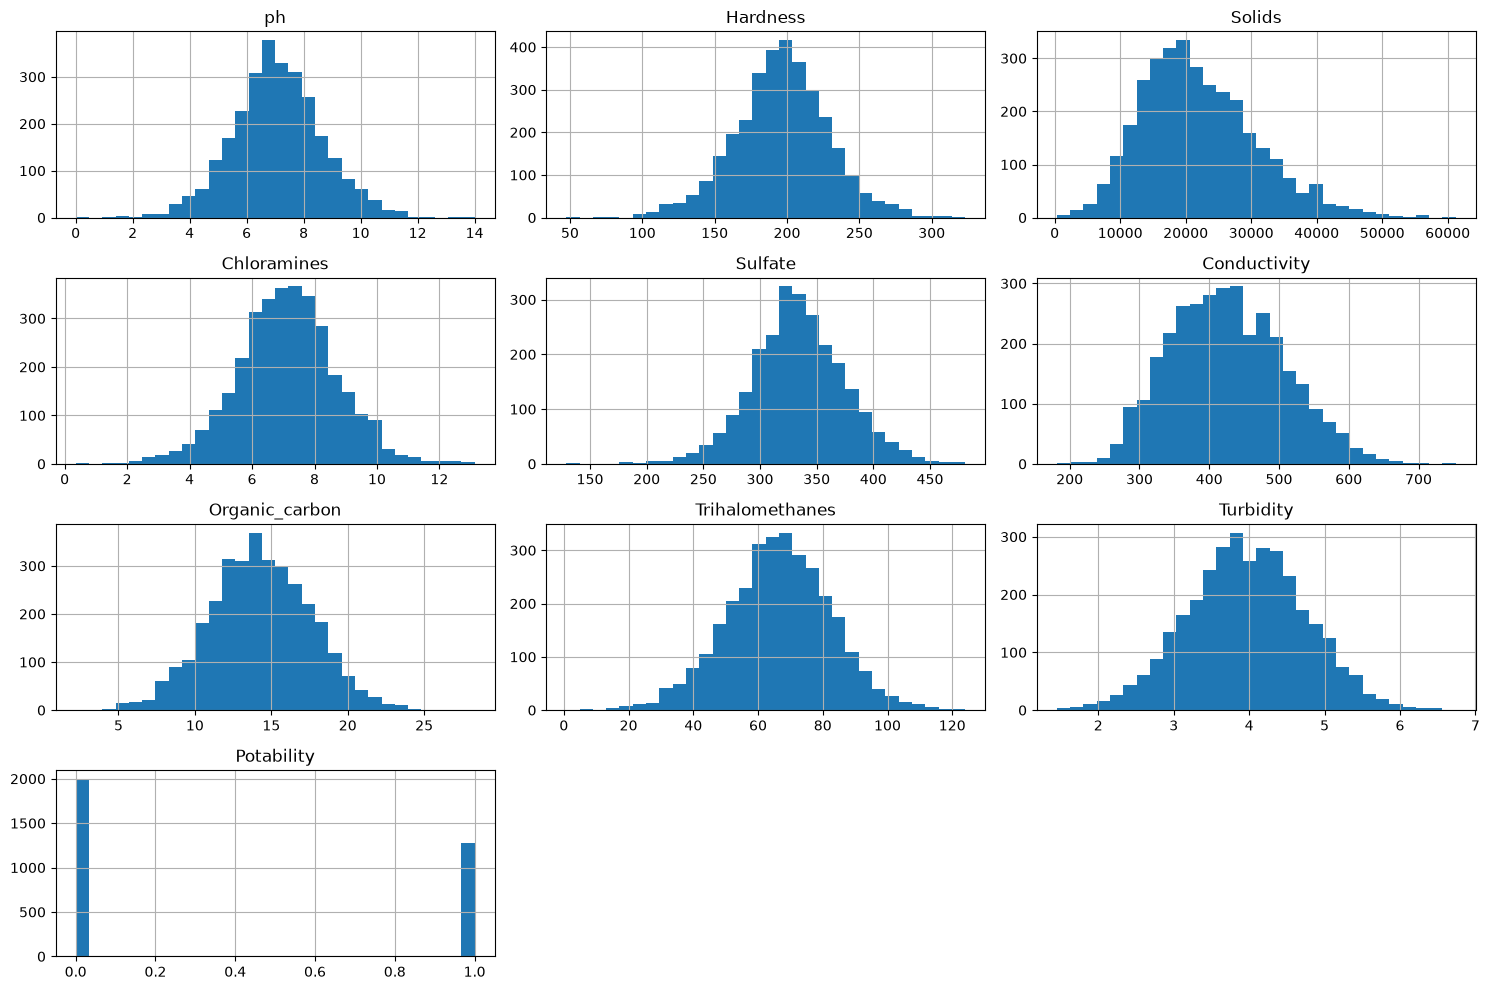

In [3]:

df.hist(figsize=(15, 10), bins=30)

plt.tight_layout()
plt.show()

UNIVARIATE ANALYSIS


Distribution Analysis: 
----------------------------------------
Count: 2785
Mean: 7.08
Median: 7.04
Q1: 6.09
Q2: 7.04
Q3: 8.06
IQR: 1.97
Variance: 2.54
Std: 1.59
cv: 0.23
Min: 0.0
Max: 14.0
Range: 14.0
Skewness: 0.03
Kurtosis: 0.72


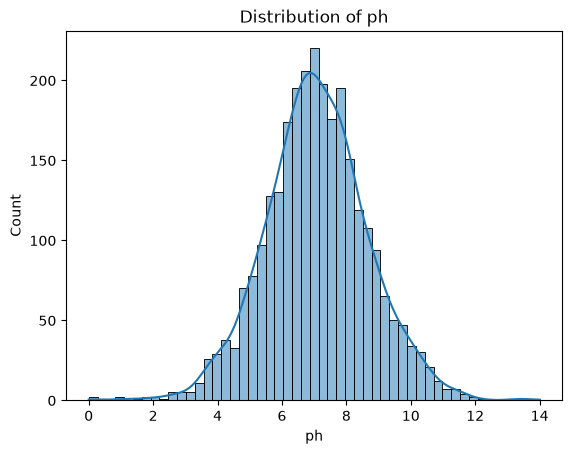

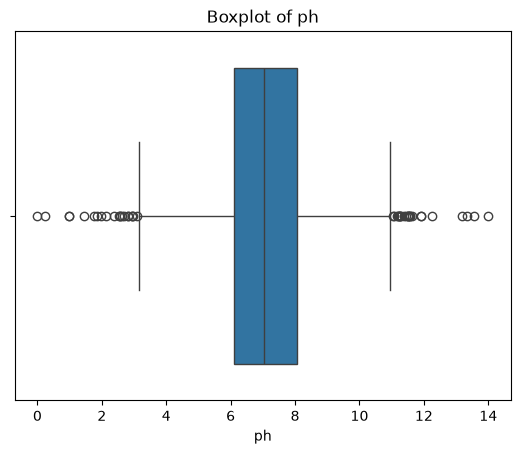

Count: 3276
Mean: 196.37
Median: 196.97
Q1: 176.85
Q2: 196.97
Q3: 216.67
IQR: 39.82
Variance: 1081.08
Std: 32.88
cv: 0.17
Min: 47.43
Max: 323.12
Range: 275.69
Skewness: -0.04
Kurtosis: 0.62


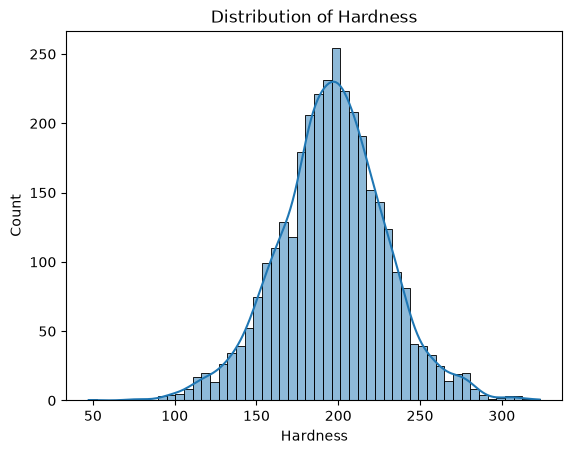

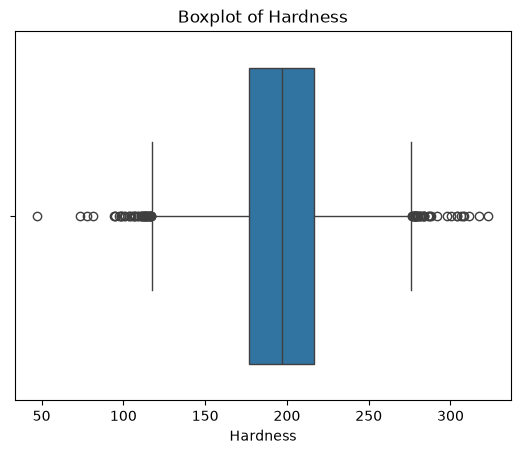

Count: 3276
Mean: 22014.09
Median: 20927.83
Q1: 15666.69
Q2: 20927.83
Q3: 27332.76
IQR: 11666.07
Variance: 76887834.36
Std: 8768.57
cv: 0.4
Min: 320.94
Max: 61227.2
Range: 60906.25
Skewness: 0.62
Kurtosis: 0.44


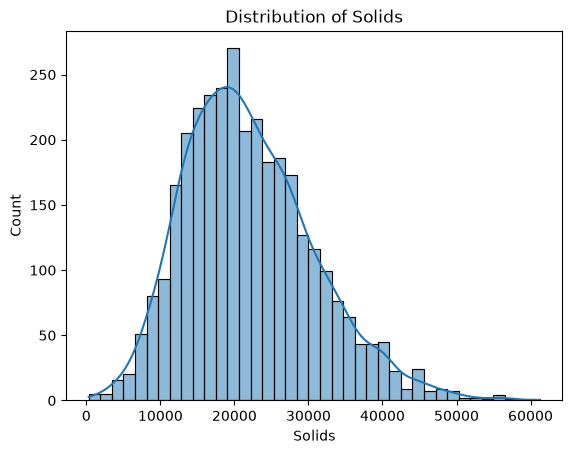

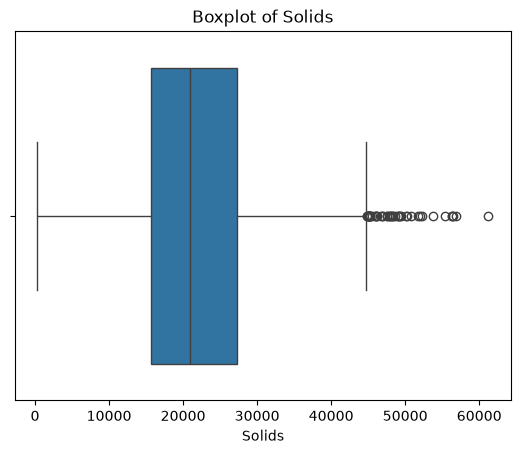

Count: 3276
Mean: 7.12
Median: 7.13
Q1: 6.13
Q2: 7.13
Q3: 8.11
IQR: 1.99
Variance: 2.51
Std: 1.58
cv: 0.22
Min: 0.35
Max: 13.13
Range: 12.78
Skewness: -0.01
Kurtosis: 0.59


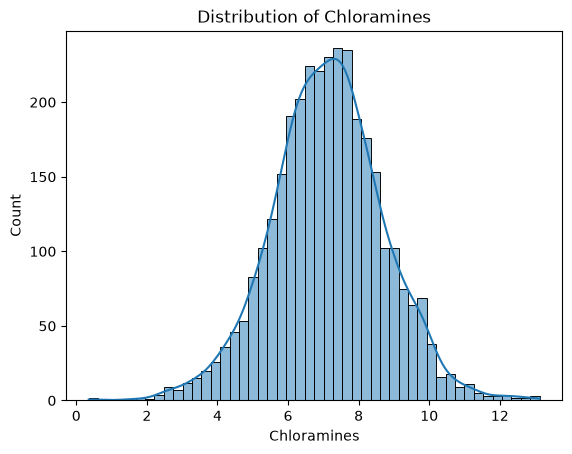

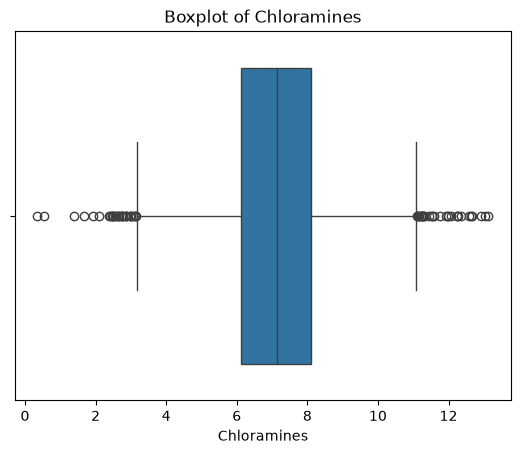

Count: 2495
Mean: 333.78
Median: 333.07
Q1: 307.7
Q2: 333.07
Q3: 359.95
IQR: 52.25
Variance: 1715.35
Std: 41.42
cv: 0.12
Min: 129.0
Max: 481.03
Range: 352.03
Skewness: -0.04
Kurtosis: 0.65


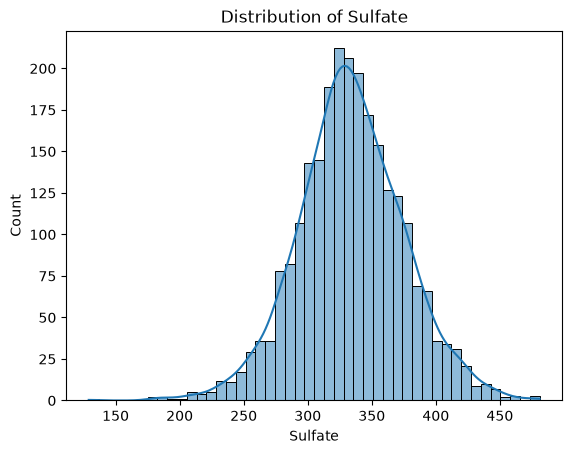

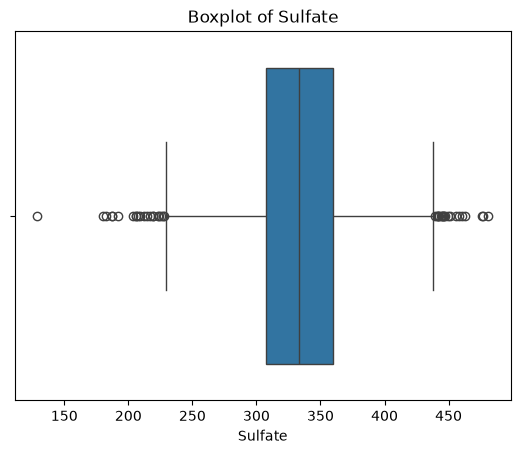

Count: 3276
Mean: 426.21
Median: 421.88
Q1: 365.73
Q2: 421.88
Q3: 481.79
IQR: 116.06
Variance: 6532.53
Std: 80.82
cv: 0.19
Min: 181.48
Max: 753.34
Range: 571.86
Skewness: 0.26
Kurtosis: -0.28


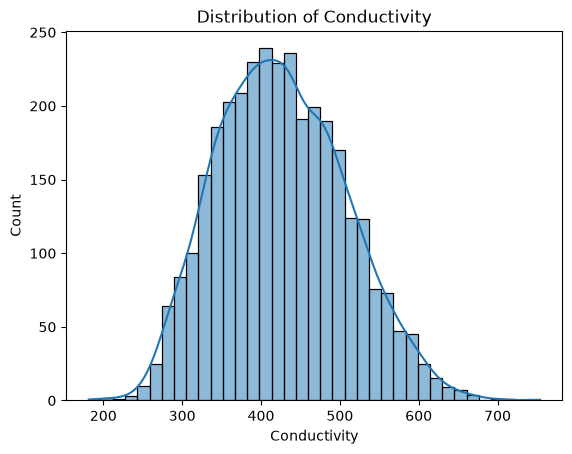

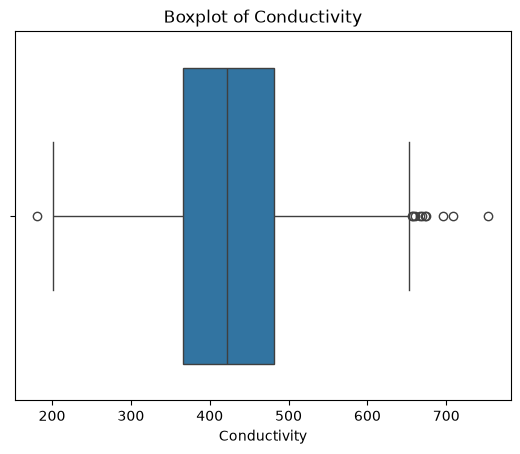

Count: 3276
Mean: 14.28
Median: 14.22
Q1: 12.07
Q2: 14.22
Q3: 16.56
IQR: 4.49
Variance: 10.94
Std: 3.31
cv: 0.23
Min: 2.2
Max: 28.3
Range: 26.1
Skewness: 0.03
Kurtosis: 0.04


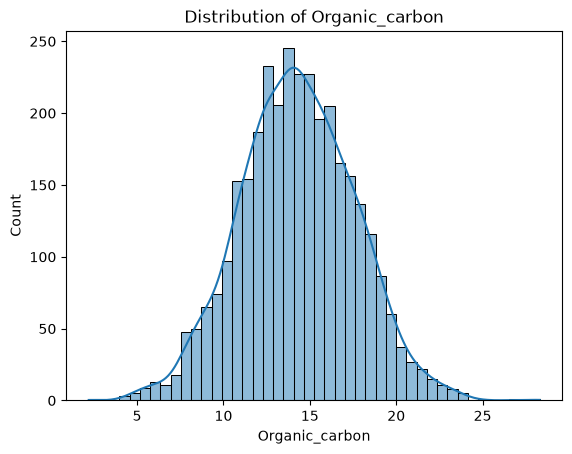

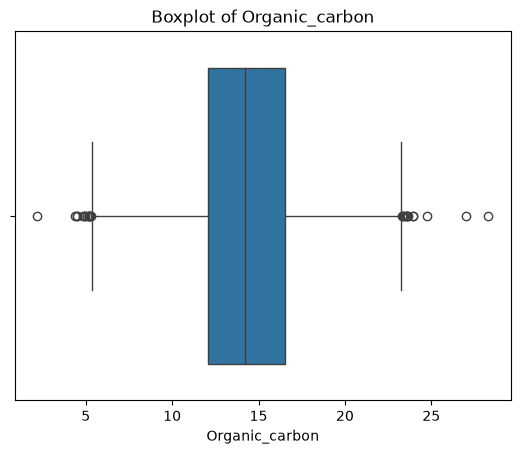

Count: 3114
Mean: 66.4
Median: 66.62
Q1: 55.84
Q2: 66.62
Q3: 77.34
IQR: 21.49
Variance: 261.63
Std: 16.18
cv: 0.24
Min: 0.74
Max: 124.0
Range: 123.26
Skewness: -0.08
Kurtosis: 0.24


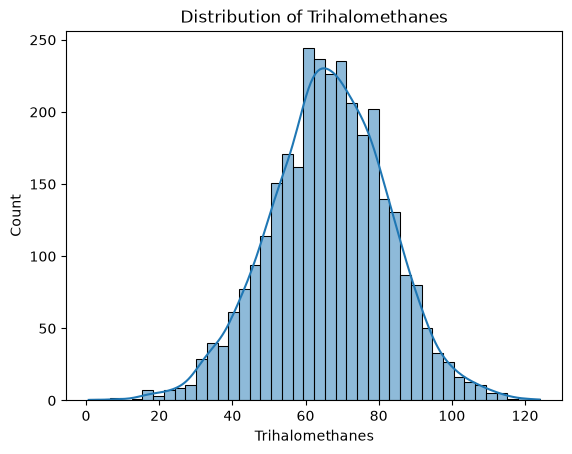

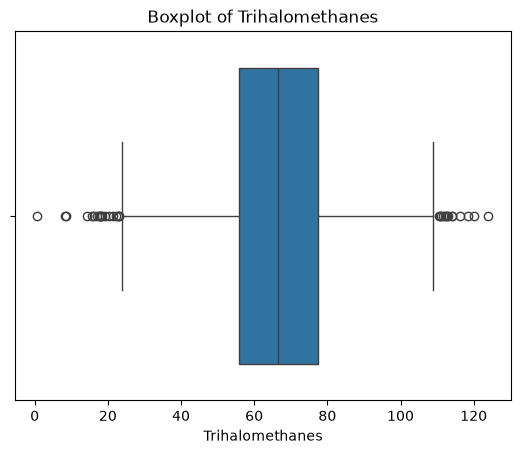

Count: 3276
Mean: 3.97
Median: 3.96
Q1: 3.44
Q2: 3.96
Q3: 4.5
IQR: 1.06
Variance: 0.61
Std: 0.78
cv: 0.2
Min: 1.45
Max: 6.74
Range: 5.29
Skewness: -0.01
Kurtosis: -0.06


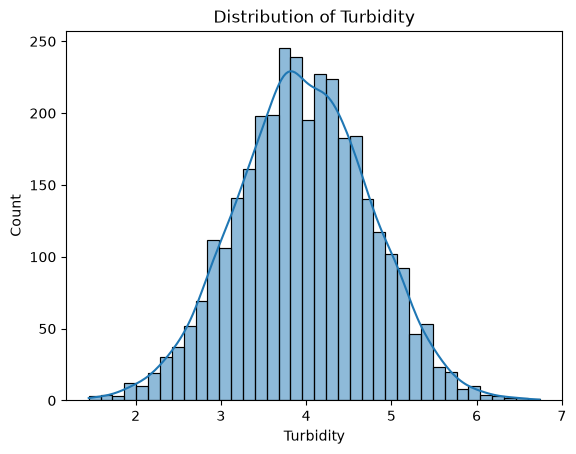

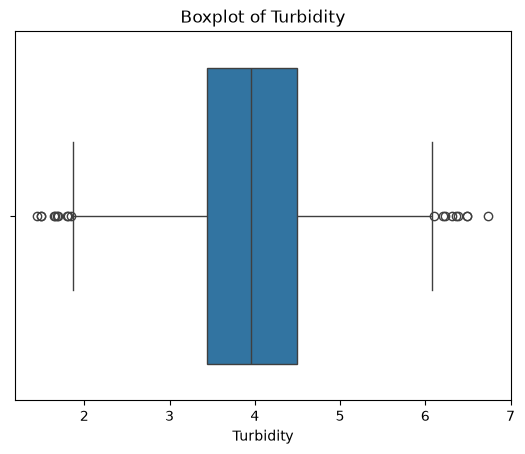

In [37]:
#numerical values


def univariat_analysis(DATAFRAME):

    print(f"Distribution Analysis: ")
    print("-" * 40)

    numeric_data = DATAFRAME.select_dtypes(include="number")
    DATA = numeric_data.drop(columns=["Potability"])

    for column in DATA.columns:

        print("Count:",round(DATA[column].count()))
        print("Mean:", round(DATA[column].mean(), 2))
        print("Median:", round(DATA[column].median(), 2))
        print("Q1:", round(DATA[column].quantile(0.25), 2))
        print("Q2:", round(DATA[column].quantile(0.50), 2))
        print("Q3:", round(DATA[column].quantile(0.75), 2))
        print("IQR:", round(DATA[column].quantile(0.75) - DATA[column].quantile(0.25), 2))
        print("Variance:", round(DATA[column].var(), 2))
        print("Std:", round(DATA[column].std(), 2))
        print("cv:", round(DATA[column].std() / DATA[column].mean() if DATA[column].mean() != 0 else 0, 2))
        print("Min:", round(DATA[column].min(), 2))
        print("Max:", round(DATA[column].max(), 2))
        print("Range:", round(DATA[column].max() - DATA[column].min(), 2))
        print("Skewness:", round(DATA[column].skew(), 2))
        print("Kurtosis:", round(DATA[column].kurt(), 2))



        series = DATA[column].dropna()
        sns.histplot(
            data=DATA,
            x=series,
            kde=True
        )

        plt.title(f"Distribution of {DATA[column].name}")
        plt.show()

        sns.boxplot(
            data=DATA,
            x=series
        )

        plt.title(f"Boxplot of {DATA[column].name}")
        plt.show()




univariat_analysis(df)

Categorical Analysis:
----------------------------------------
Column: Potability
Count: 3276
Missing: 0
Unique: 2
Mode: 0

Value Counts:
Potability
0    1998
1    1278
Name: count, dtype: int64

Percentage:
Potability
0    60.99
1    39.01
Name: proportion, dtype: float64
----------------------------------------


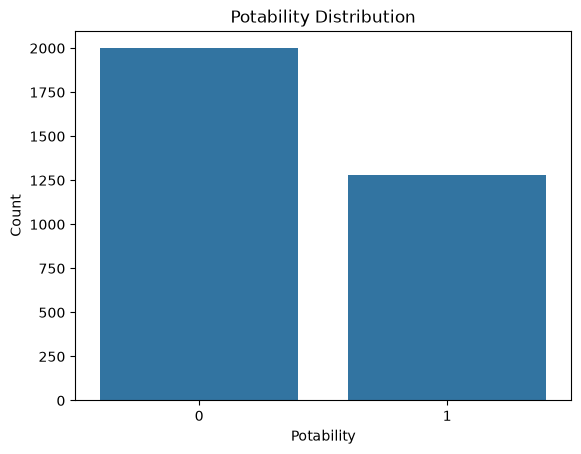

In [28]:
#Categorical values

def categorical_analysis():

    print("Categorical Analysis:")
    print("-" * 40)

    DATA = df["Potability"]

    print(f"Column: {DATA.name}")
    print("Count:", DATA.count())
    print("Missing:", DATA.isna().sum())
    print("Unique:", DATA.nunique())
    print("Mode:", DATA.mode()[0])

    print("\nValue Counts:")
    print(DATA.value_counts())

    print("\nPercentage:")
    print(DATA.value_counts(normalize=True).mul(100).round(2))

    print("-" * 40)


    sns.countplot(data=df, x="Potability")

    plt.title("Potability Distribution")
    plt.xlabel("Potability")
    plt.ylabel("Count")
    plt.show()


categorical_analysis()

BIVARIATE ANALYSIS


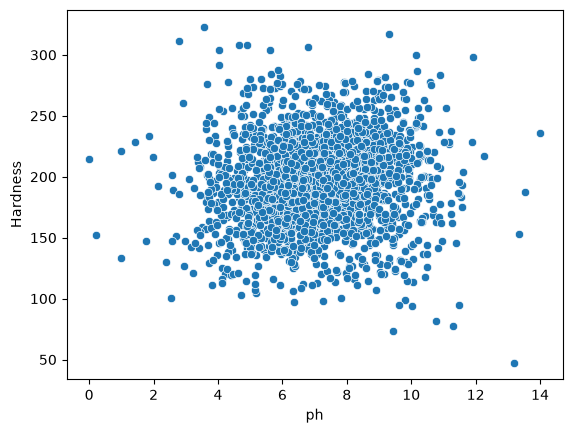

0.08209640686603727


In [30]:
sns.scatterplot(x="ph", y="Hardness", data=df)
plt.show()

correlation = df["ph"].corr(df["Hardness"])
print(correlation)

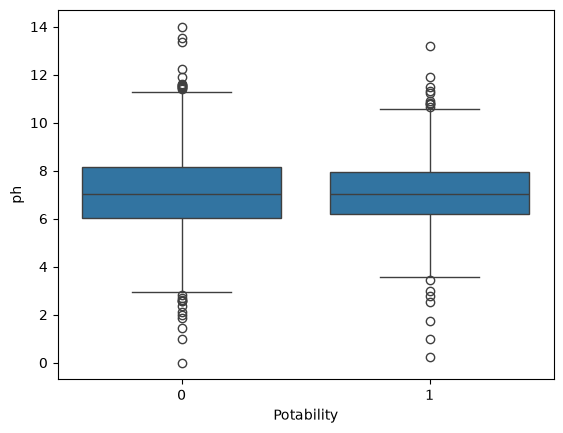

In [31]:
sns.boxplot(x="Potability", y="ph", data=df)
plt.show()

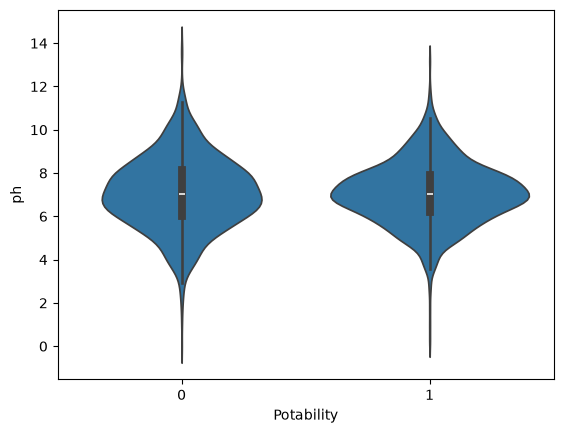

In [32]:
sns.violinplot(x="Potability", y="ph", data=df)
plt.show()


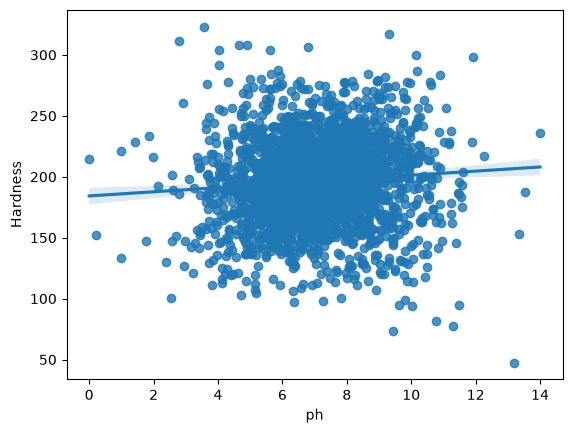

In [33]:
sns.regplot(x="ph", y="Hardness", data=df)
plt.show()

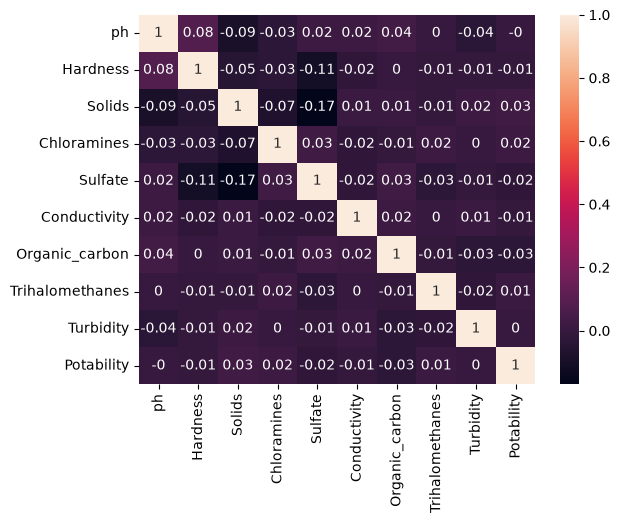

In [35]:
corr = round(df.corr(numeric_only=True), 2)

sns.heatmap(corr, annot=True)
plt.show()

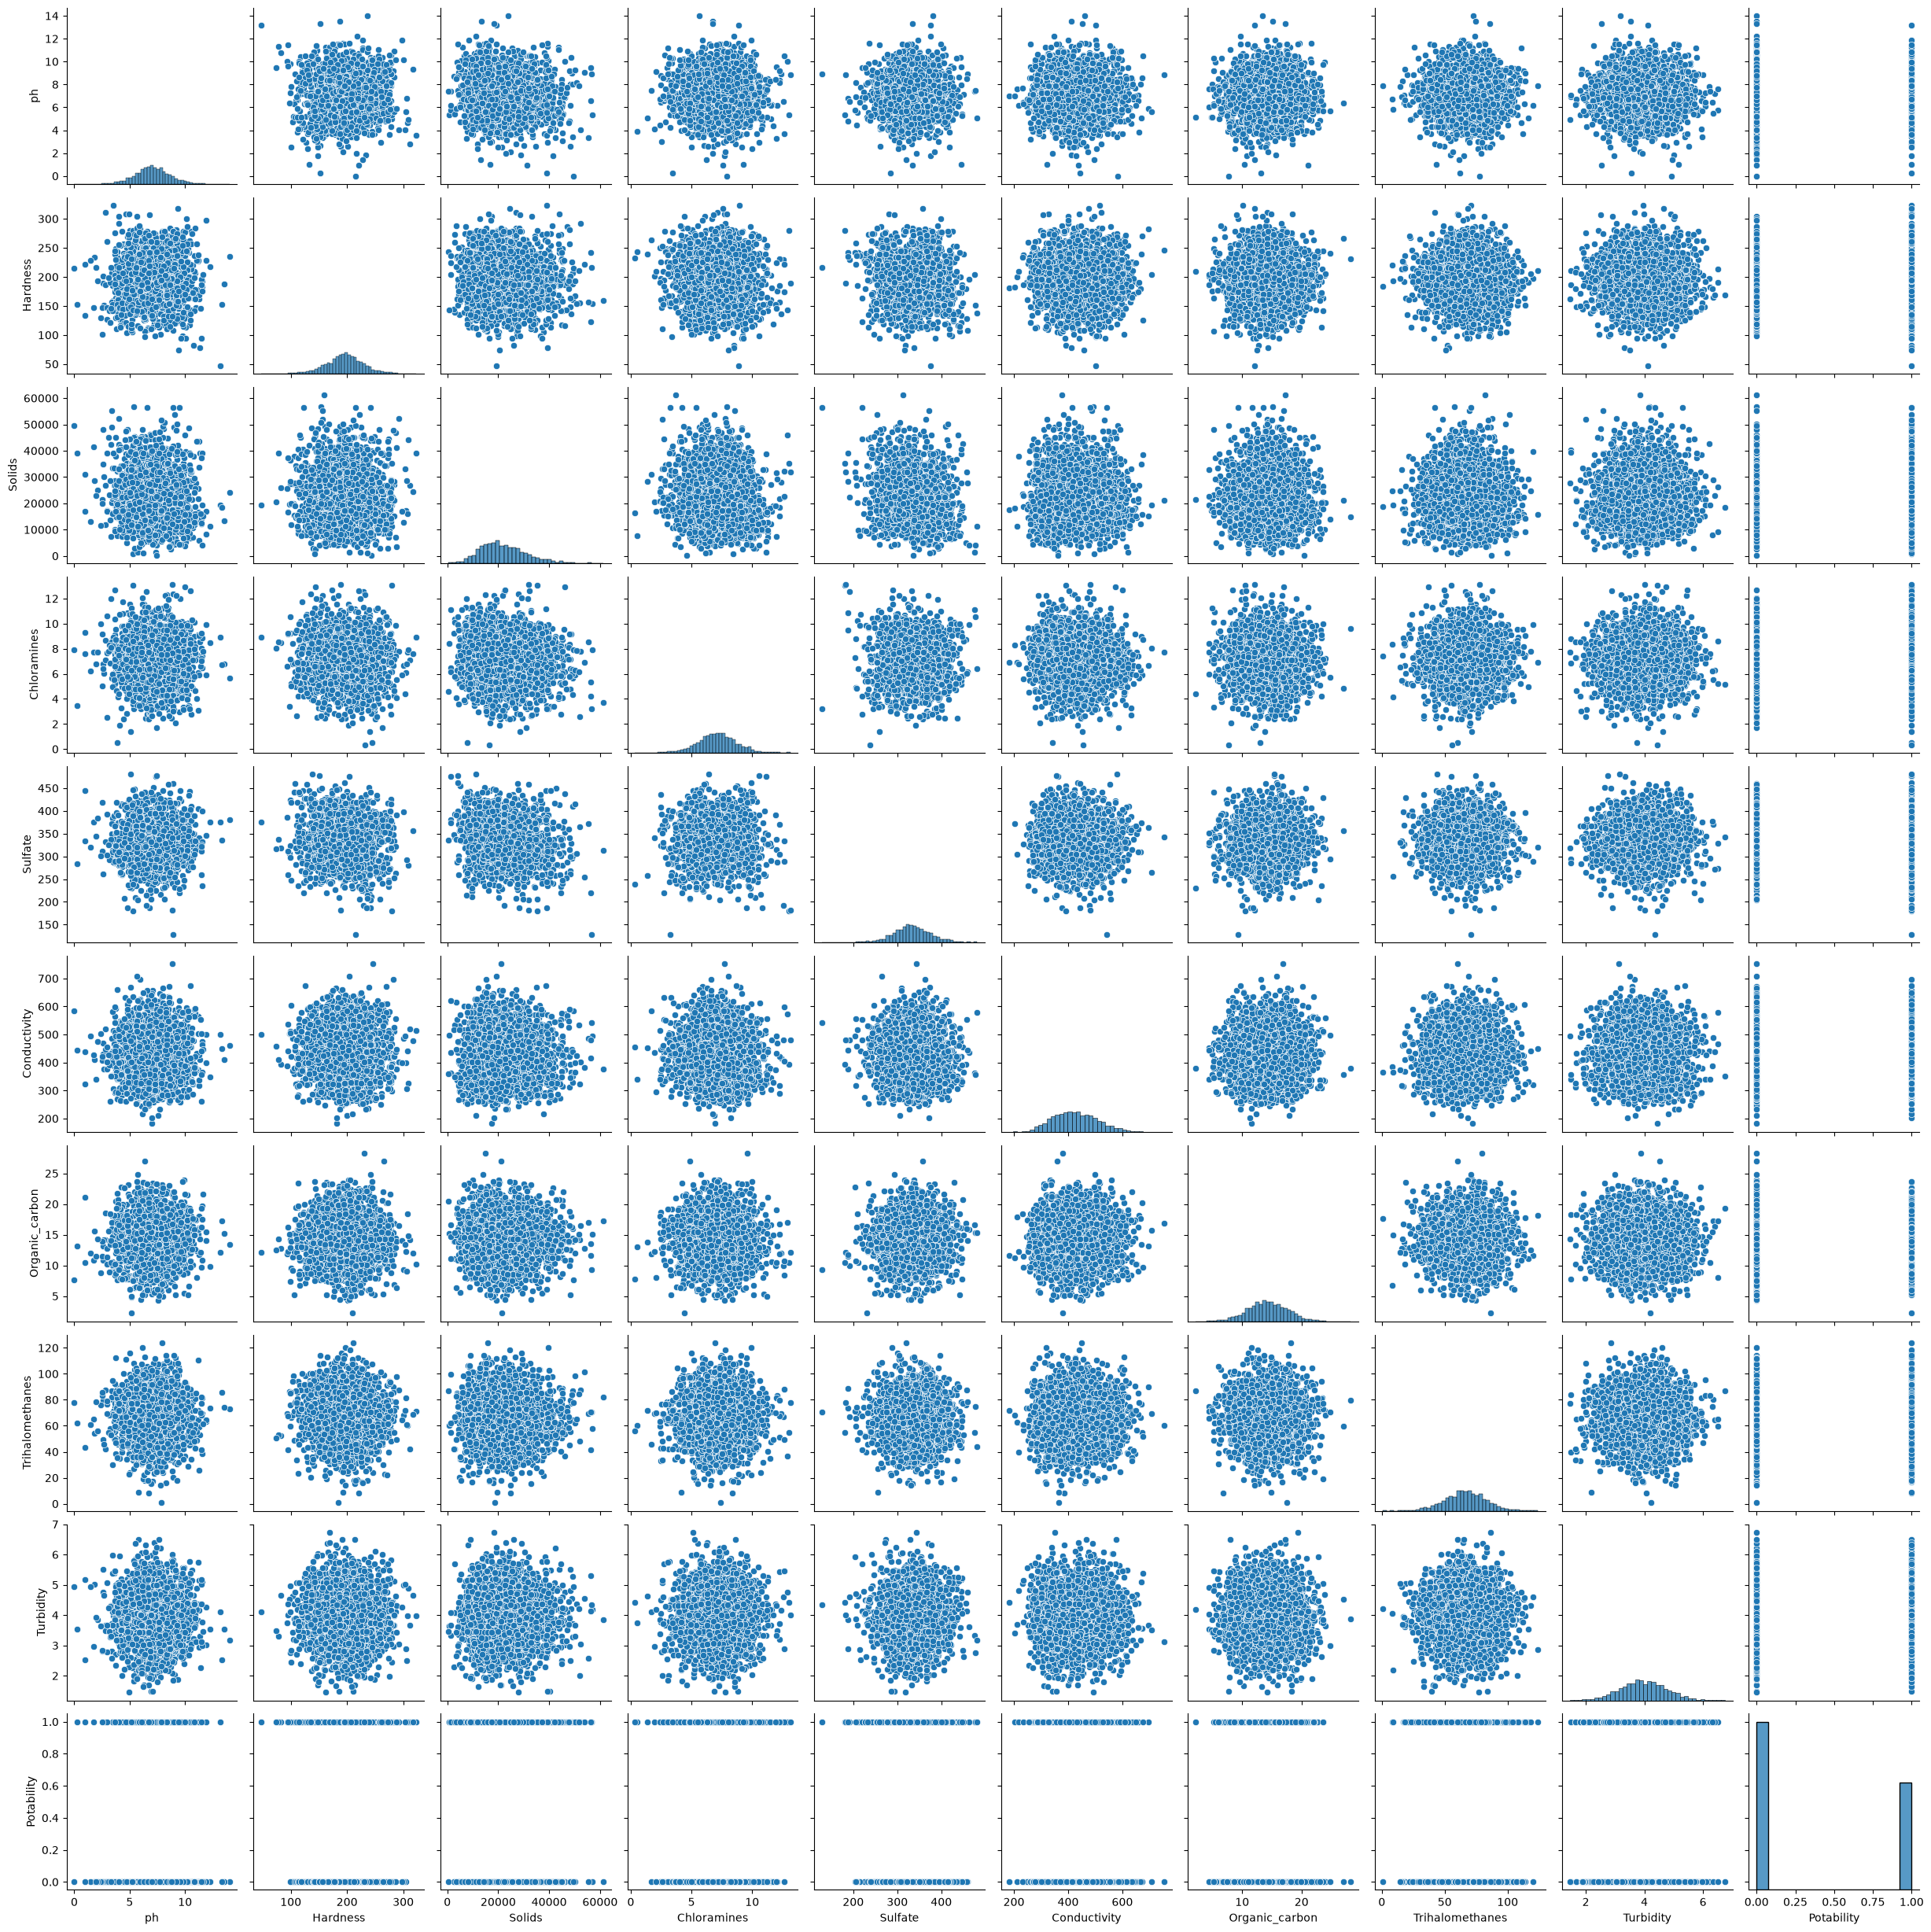

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df.select_dtypes(include="number")

sns.pairplot(numerical_df)
plt.show()

In [38]:
# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Print correlation matrix
print(corr_matrix.round(3))

                    ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
ph               1.000     0.082  -0.089       -0.034    0.018         0.019   
Hardness         0.082     1.000  -0.047       -0.030   -0.107        -0.024   
Solids          -0.089    -0.047   1.000       -0.070   -0.172         0.014   
Chloramines     -0.034    -0.030  -0.070        1.000    0.027        -0.020   
Sulfate          0.018    -0.107  -0.172        0.027    1.000        -0.016   
Conductivity     0.019    -0.024   0.014       -0.020   -0.016         1.000   
Organic_carbon   0.044     0.004   0.010       -0.013    0.031         0.021   
Trihalomethanes  0.003    -0.013  -0.009        0.017   -0.030         0.001   
Turbidity       -0.039    -0.014   0.020        0.002   -0.011         0.006   
Potability      -0.004    -0.014   0.034        0.024   -0.024        -0.008   

                 Organic_carbon  Trihalomethanes  Turbidity  Potability  
ph                        0.044            0.

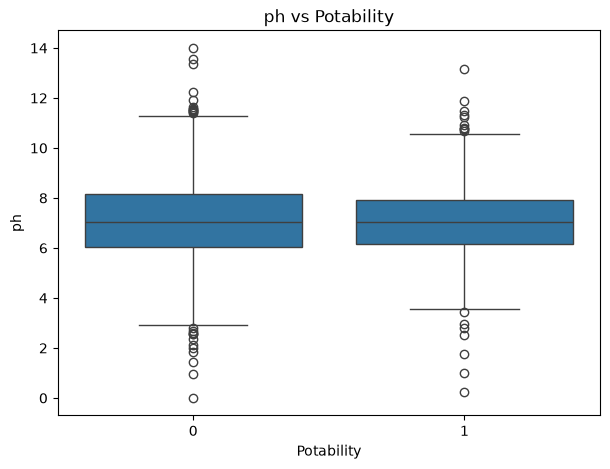

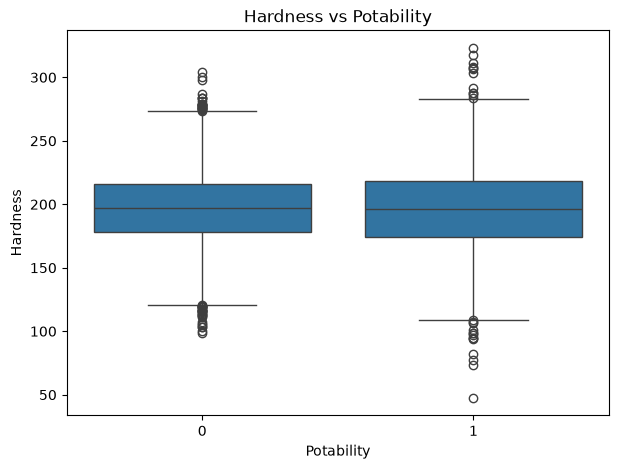

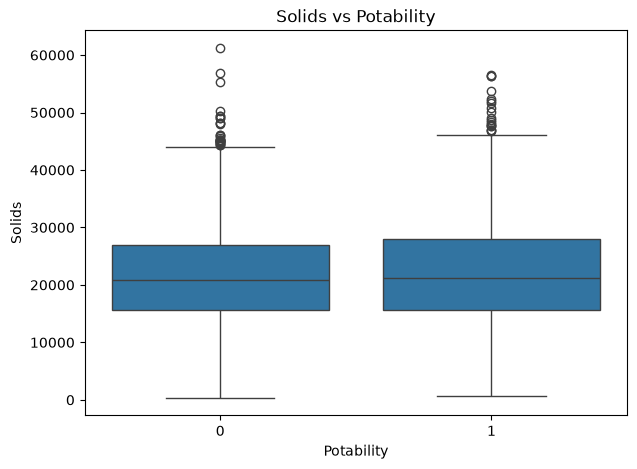

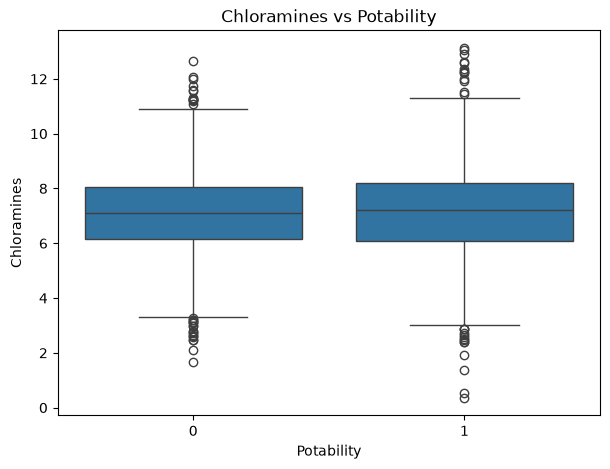

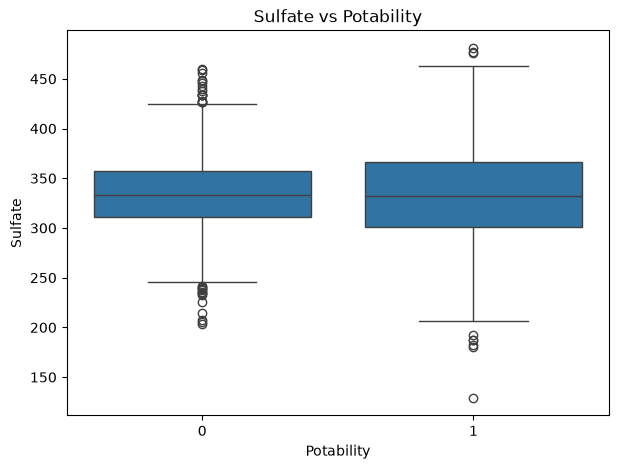

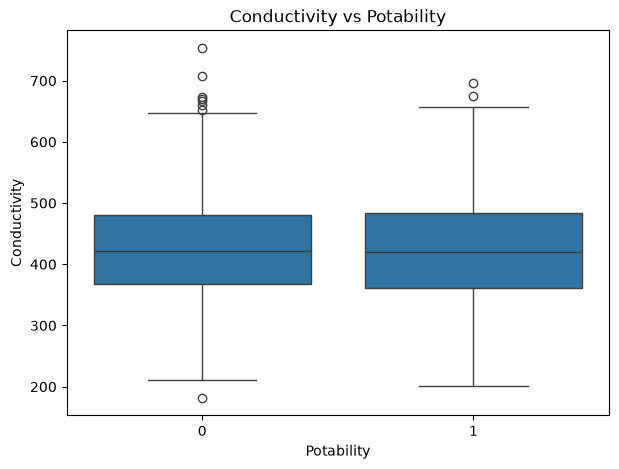

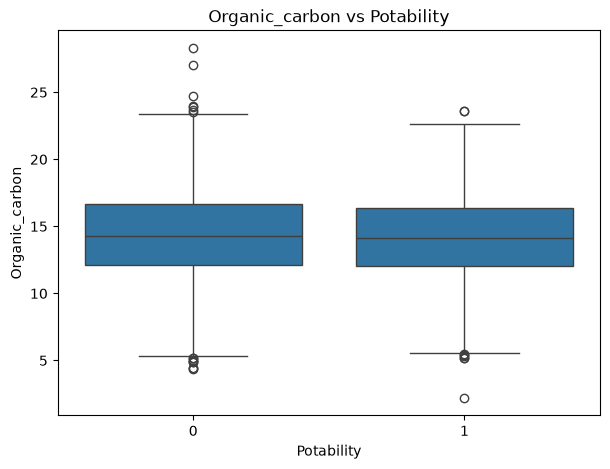

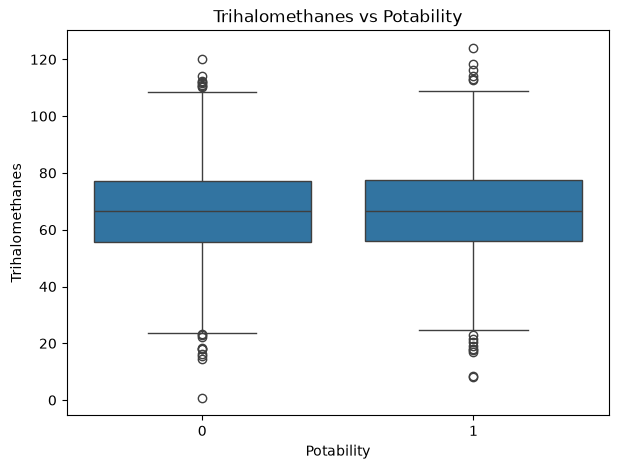

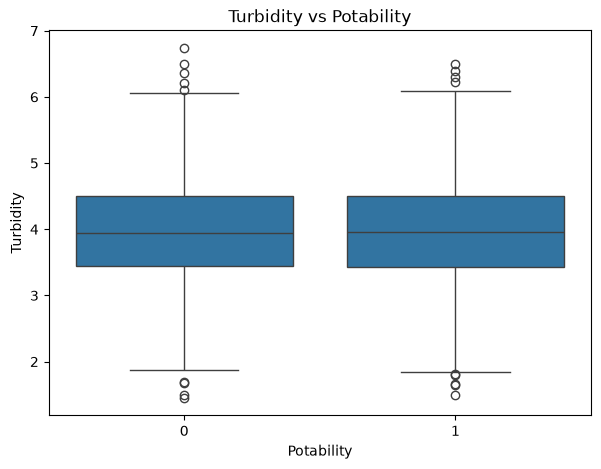

In [39]:
features = df.select_dtypes(include="number").columns.drop("Potability")

for feature in features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="Potability", y=feature)
    plt.title(f"{feature} vs Potability")
    plt.show()

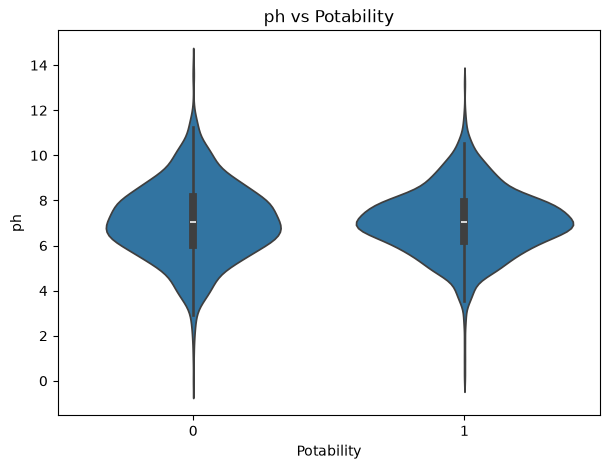

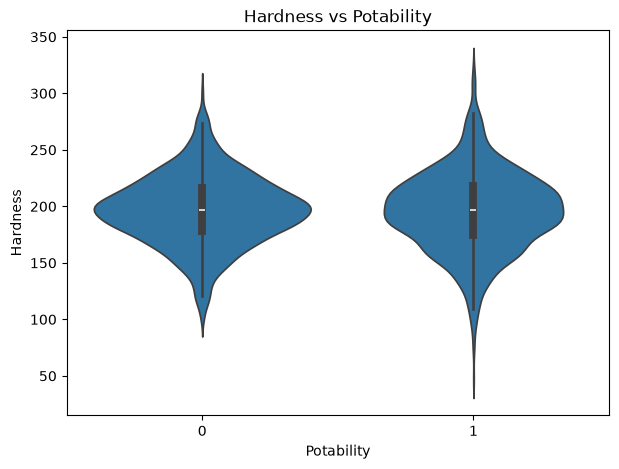

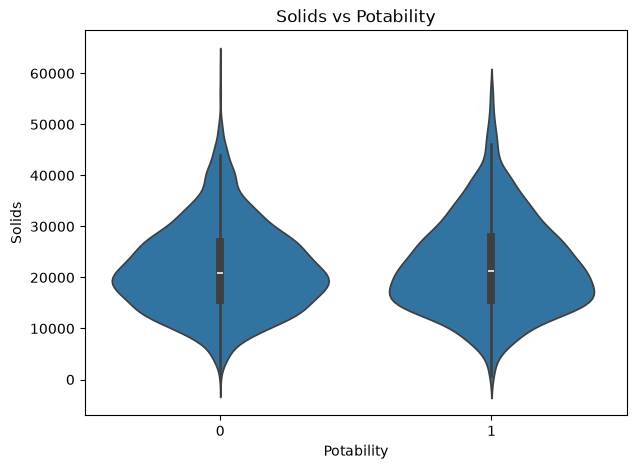

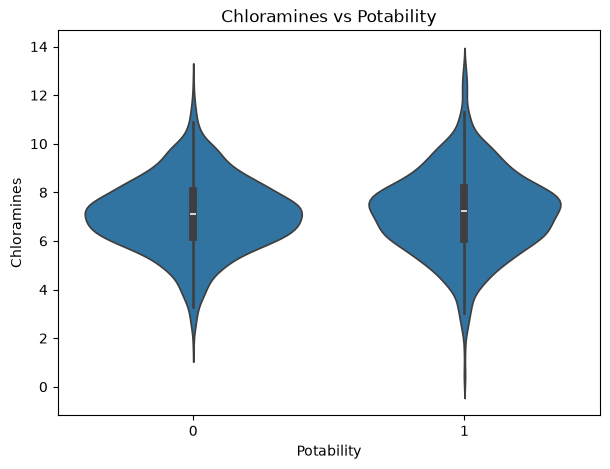

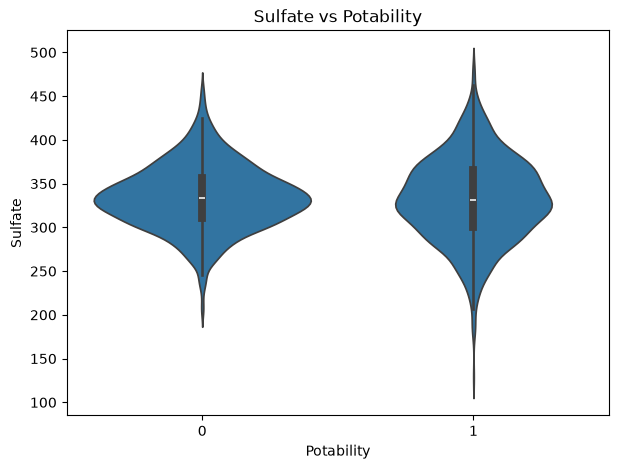

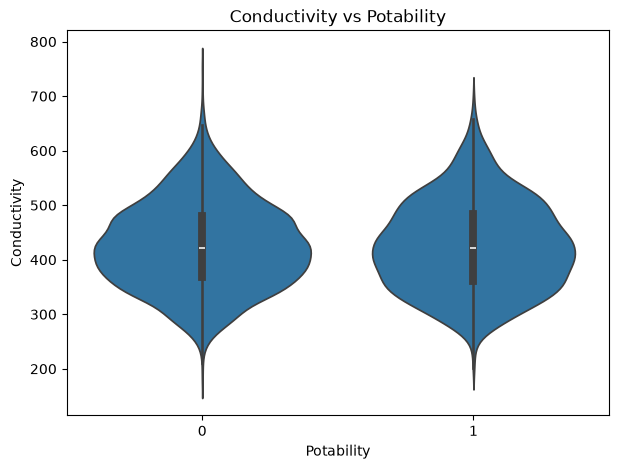

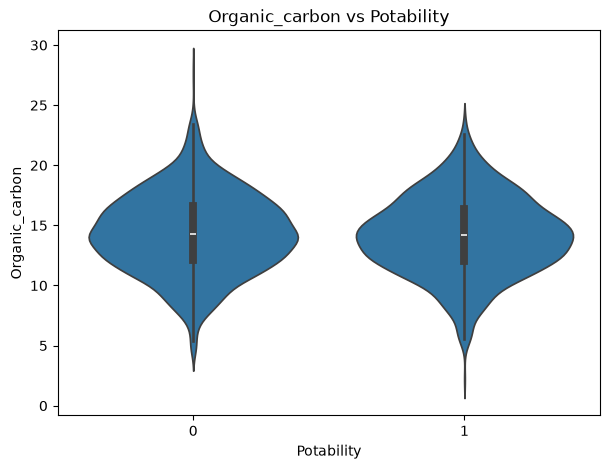

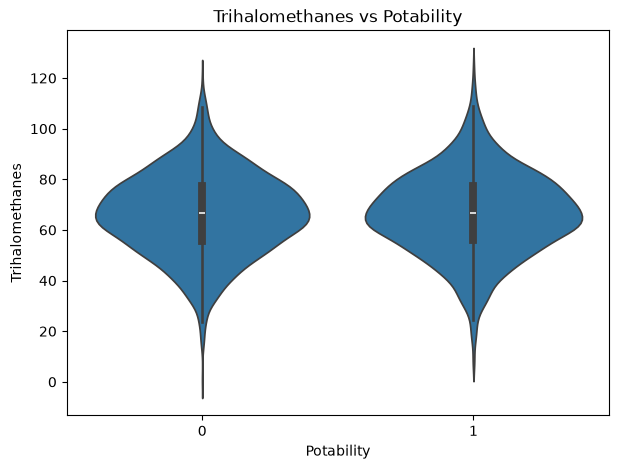

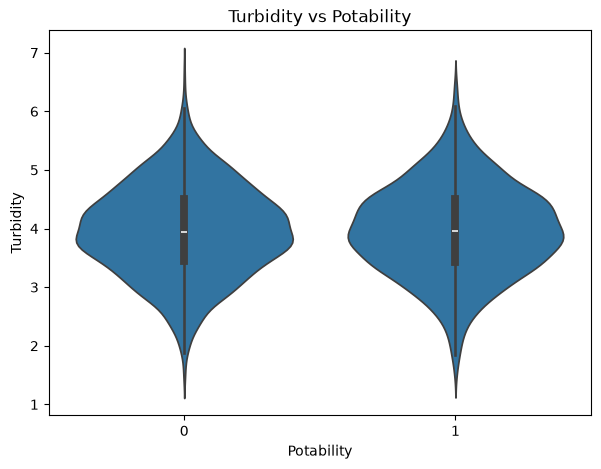

In [40]:
for feature in features:
    plt.figure(figsize=(7, 5))
    sns.violinplot(data=df, x="Potability", y=feature)
    plt.title(f"{feature} vs Potability")
    plt.show()

In [42]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns="Potability")
y = df["Potability"].dropna()

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

print(mi)

ValueError: Input X contains NaN.

REGGRESSION ANALYSIS
